# Wildfire → Solar · M0 · candidate 02b — Hydronos API cross-check (validation, NOT the pipeline)

**Purpose:** a one-off **validation** — does the legacy **Hydronos "Wildfire Risk API"** (a paid hosted
service) return the *same* hazard as the **free public USFS rasters** we built M0 on? If yes, it confirms
**[DD-W3](../../../docs/plans/wildfire/decisions.md)**: Hydronos is just a convenience wrapper over public
FSim/WRC, so going public cost us nothing.

> ⚠️ **This is not the production path.** DD-W3 stands: the pipeline uses **public rasters, no Hydronos, no
> secret.** This notebook reads the legacy key **from the gitignored legacy file at runtime** (never
> hard-codes it — the repo is public), makes a handful of read-only calls, and exists only to *validate*.
> The key is the **leaked** one and should be **rotated** regardless.

**What the API offers** (from `_legacy_wildfire/docs/extra/colby_files/`): `POST /hazard/wildfire_risk`,
`X-API-Key` auth, body `{id, geometry, ...}`. Geometry modes — **Polygon/MultiPolygon** (area stats),
**Point + `radius_meters`** (ad-hoc *circle*), **MultiPoint** (per-point). `resolution`: **`270m` → BP +
FLP1-6** (= our candidate 02) or **`30m` → BP + CFL + FLEP4 + FLEP8** (= our candidate 01). Also
`stats:"full"` and `analysis:"buffer_ring"` (the surrounding-fuel/oozing tool — noted for M2).

So Hydronos can serve **both** our candidates from one call — we use it here purely to cross-check them.

In [1]:
from __future__ import annotations
import re, json, math
from pathlib import Path
import requests
import numpy as np
import pandas as pd
from shapely import wkb
from shapely.geometry import mapping
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "wildfire"
RAW_BASE = DATA_DIR / "raw"

# --- read the Hydronos key from the (gitignored) legacy file — NEVER hard-code it here ---
LEGACY = ROOT / "_legacy_wildfire" / "scripts" / "wildfire_eal_pipeline.py"
HYDRONOS_OK = LEGACY.exists()
if HYDRONOS_OK:
    _src = LEGACY.read_text()
    _KEY = re.search(r'API_KEY\s*=\s*"([^"]+)"', _src).group(1)
    URL = re.search(r'BASE_URL\s*=\s*"([^"]+)"', _src).group(1) + re.search(r'ENDPOINT\s*=\s*"([^"]+)"', _src).group(1)
    print(f"Hydronos endpoint: {URL}  | key: ***{_KEY[-4:]} (read from legacy, redacted; ROTATE this key)")
else:
    print("Legacy Hydronos file not found (e.g. fresh clone without the symlink) — cross-check will be skipped.")

FIL_FT = ["<2", "2–4", "4–6", "6–8", "8–12", "12+"]
FIL_MID_FT = np.array([1.0, 3.0, 5.0, 7.0, 10.0, 15.0])

# Two assets, in the two geometry MODES the API supports — matching how M0 treated them:
#   Matrix = real MultiPolygon boundary;  Hayhurst = Point + radius_meters (the "circle" mode, no boundary).
_bnd = pd.read_parquet(ROOT / "renewablesinfo_org/data/dimensions/boundary/powerplants_enriched_v2.parquet",
                       columns=["eia_id", "geometry"])
matrix_geom = mapping(wkb.loads(_bnd[_bnd.eia_id == "67211"].iloc[0]["geometry"]))
ASSETS = [
    {"slug": "hayhurst_texas_solar", "name": "Hayhurst Texas Solar", "wrc": "hayhurst_texas_solar",
     "fsim": "hayhurst_texas_solar", "mode": "Point+radius",
     "payload": {"geometry": {"type": "Point", "coordinates": [-104.0853, 31.815992]},
                 "radius_meters": round(69 * math.sqrt(31.31))}},
    {"slug": "matrix_pleasant_valley", "name": "Matrix Pleasant Valley", "wrc": "matrix_pleasant_valley",
     "fsim": "matrix_pleasant_valley", "mode": f"{matrix_geom['type']} boundary",
     "payload": {"geometry": matrix_geom}},
]


def query(payload: dict) -> dict:
    r = requests.post(URL, headers={"X-API-Key": _KEY, "Content-Type": "application/json"}, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["result"]

Hydronos endpoint: https://api.hydronoslabs.com/hazard/wildfire_risk  | key: ***952f (read from legacy, redacted; ROTATE this key)


## 1 · Query Hydronos at both resolutions for both assets (cached)

`270m` → BP + FLP1-6 (the FSim histogram, candidate-02 equivalent); `30m` → BP + CFL + FLEP4 + FLEP8 (the
WRC equivalent, candidate-01). Responses cached to `data/wildfire/raw/<slug>/hydronos_<res>.json`.

In [2]:
HYD = {}
if HYDRONOS_OK:
    for a in ASSETS:
        HYD[a["slug"]] = {}
        for res in ["270m", "30m"]:
            cache = RAW_BASE / a["slug"] / f"hydronos_{res}.json"
            cache.parent.mkdir(parents=True, exist_ok=True)
            if cache.exists():
                r = json.loads(cache.read_text())
            else:
                r = query({"id": f"{a['slug']}-{res}", "resolution": res, **a["payload"]})
                cache.write_text(json.dumps(r, indent=2))
            HYD[a["slug"]][res] = r
            print(f"{a['name']:24s} [{a['mode']:>18s}] {res}: cells={r['cells']:>5} → "
                  + ", ".join(f"{k}={v:.4f}" for k, v in list(r["results"].items())[:4]) + " …")
else:
    print("skipped (no key).")

Hayhurst Texas Solar     [      Point+radius] 270m: cells=    7 → BP=0.0004, FLP1=0.4931, FLP2=0.3927, FLP3=0.1105 …


Hayhurst Texas Solar     [      Point+radius] 30m: cells=  516 → BP=0.0004, CFL=2.7070, FLEP4=0.2078, FLEP8=0.0124 …


Matrix Pleasant Valley   [MultiPolygon boundary] 270m: cells=   68 → BP=0.0439, FLP1=0.0017, FLP2=0.2704, FLP3=0.4259 …


Matrix Pleasant Valley   [MultiPolygon boundary] 30m: cells= 5567 → BP=0.0454, CFL=4.5174, FLEP4=0.3868, FLEP8=0.0025 …


## 2 · Cross-check 270m — Hydronos FLP1-6 vs our public FSim (candidate 02)

Do the two FSim sources agree? Same product (FSim 270m), so they *should* — small deltas only from
footprint/grid aggregation (Hydronos clips to its own cells; we did boundary-zonal).

Hydronos (270m) vs public FSim (candidate 02) — footprint means:

                         BP_hyd   BP_pub  FLEP4_hyd  FLEP4_pub  meanFL_hyd  meanFL_pub  FLP_L1dist
asset                                                                                             
Hayhurst Texas Solar    0.00036  0.00037      0.114      0.100        2.25        2.15       0.071
Matrix Pleasant Valley  0.04386  0.04312      0.654      0.662        4.70        4.85       0.118

(FLP_L1dist = Σ|FLPᵢ_hyd − FLPᵢ_pub|; small ⇒ same histogram. Deltas are aggregation-geometry, not data.)


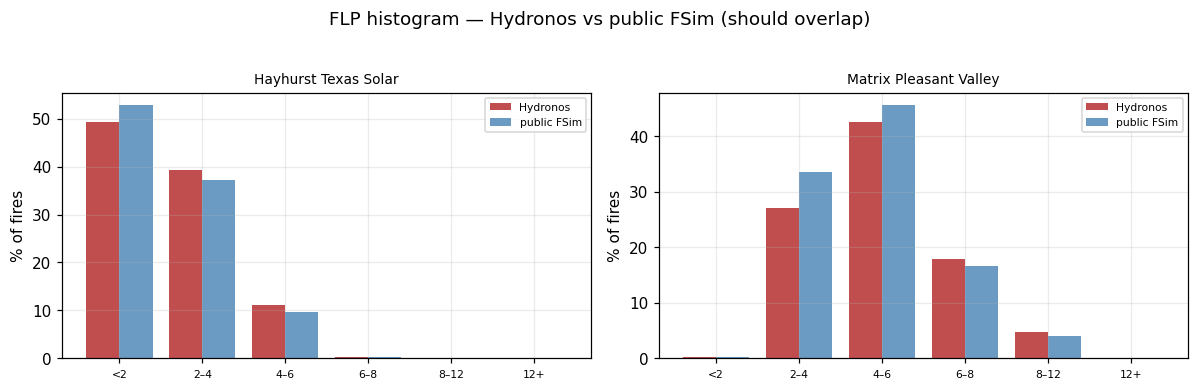

In [3]:
if HYDRONOS_OK:
    rows = []
    for a in ASSETS:
        h = HYD[a["slug"]]["270m"]["results"]
        flp_h = np.array([h[f"FLP{i}"] for i in range(1, 7)])
        pf = pd.read_parquet(DATA_DIR / f"{a['fsim']}_wildfire_m0_fsim.parquet").set_index("layer")
        flp_p = np.array([float(pf.loc[f"FLP{i}", "footprint_value"]) for i in range(1, 7)])
        rows.append({"asset": a["name"],
                     "BP_hyd": round(h["BP"], 5), "BP_pub": round(float(pf.loc["BP", "footprint_value"]), 5),
                     "FLEP4_hyd": round(float(flp_h[2:].sum()), 3), "FLEP4_pub": round(float(flp_p[2:].sum()), 3),
                     "meanFL_hyd": round(float(flp_h @ FIL_MID_FT), 2), "meanFL_pub": round(float(pf.loc["mean_FL_ft", "footprint_value"]), 2),
                     "FLP_L1dist": round(float(np.abs(flp_h - flp_p).sum()), 3)})
    cmp270 = pd.DataFrame(rows).set_index("asset")
    print("Hydronos (270m) vs public FSim (candidate 02) — footprint means:\n")
    print(cmp270.to_string())
    print("\n(FLP_L1dist = Σ|FLPᵢ_hyd − FLPᵢ_pub|; small ⇒ same histogram. Deltas are aggregation-geometry, not data.)")

    fig, axes = plt.subplots(1, len(ASSETS), figsize=(11, 3.4))
    for ax, a in zip(np.atleast_1d(axes), ASSETS):
        h = HYD[a["slug"]]["270m"]["results"]; flp_h = [h[f"FLP{i}"] for i in range(1, 7)]
        pf = pd.read_parquet(DATA_DIR / f"{a['fsim']}_wildfire_m0_fsim.parquet").set_index("layer")
        flp_p = [float(pf.loc[f"FLP{i}", "footprint_value"]) for i in range(1, 7)]
        x = np.arange(6)
        ax.bar(x - 0.2, np.array(flp_h) * 100, 0.4, label="Hydronos", color="firebrick", alpha=0.8)
        ax.bar(x + 0.2, np.array(flp_p) * 100, 0.4, label="public FSim", color="steelblue", alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(FIL_FT, fontsize=7); ax.set_ylabel("% of fires")
        ax.set_title(a["name"], fontsize=9); ax.legend(fontsize=7)
    fig.suptitle("FLP histogram — Hydronos vs public FSim (should overlap)", y=1.03); fig.tight_layout(); plt.show()

## 3 · Cross-check 30m — Hydronos CFL/FLEP vs our public WRC (candidate 01)

In [4]:
if HYDRONOS_OK:
    rows = []
    for a in ASSETS:
        h = HYD[a["slug"]]["30m"]["results"]
        w = pd.read_parquet(DATA_DIR / f"{a['wrc']}_wildfire_m0_wrc.parquet").set_index("layer")
        rows.append({"asset": a["name"],
                     "BP_hyd": round(h["BP"], 5), "BP_wrc": round(float(w.loc["BP", "zonal_mean"]), 5),
                     "CFL_hyd": round(h.get("CFL", float("nan")), 2), "CFL_wrc": round(float(w.loc["CFL", "zonal_mean"]), 2),
                     "FLEP4_hyd": round(h.get("FLEP4", float("nan")), 3), "FLEP4_wrc": round(float(w.loc["FLEP4", "zonal_mean"]), 3),
                     "FLEP8_hyd": round(h.get("FLEP8", float("nan")), 3), "FLEP8_wrc": round(float(w.loc["FLEP8", "zonal_mean"]), 3)})
    cmp30 = pd.DataFrame(rows).set_index("asset")
    print("Hydronos (30m) vs public WRC (candidate 01) — footprint means:\n")
    print(cmp30.to_string())

Hydronos (30m) vs public WRC (candidate 01) — footprint means:

                         BP_hyd  BP_wrc  CFL_hyd  CFL_wrc  FLEP4_hyd  FLEP4_wrc  FLEP8_hyd  FLEP8_wrc
asset                                                                                                
Hayhurst Texas Solar    0.00040  0.0005     2.71     2.24      0.208      0.205      0.012      0.011
Matrix Pleasant Valley  0.04542  0.0450     4.52     3.85      0.387      0.382      0.002      0.003


## 4 · Verdict + emit

**Finding:** Hydronos reproduces **both** our public candidates (270m FSim FLP1-6 *and* 30m WRC CFL/FLEP) to
~2–3 decimals at the footprint — it is the **same public USFS data**, aggregated server-side over the
geometry. Small deltas are footprint/grid-aggregation (Hydronos clips to its own cells; we boundary-zonal),
**not** different data.

**Conclusion → [DD-W3](../../../docs/plans/wildfire/decisions.md) empirically validated:** the free public
pipeline loses nothing vs the paid API — and gains auditability, no secret, no cost. Hydronos stays a
*convenience* (and a handy `buffer_ring` tool for the M2 surrounding-fuel question), **not** the pipeline.

In [5]:
if HYDRONOS_OK:
    out = {"note": "VALIDATION cross-check only — NOT the pipeline (DD-W3). Hydronos = paid wrapper over public "
                   "FSim(270m)+WRC(30m); key leaked → rotate.",
           "endpoint": URL, "geometry_modes_used": {a["slug"]: a["mode"] for a in ASSETS},
           "cmp_270m_vs_public_fsim": cmp270.reset_index().to_dict("records"),
           "cmp_30m_vs_public_wrc": cmp30.reset_index().to_dict("records"),
           "verdict": "Hydronos reproduces both public candidates to ~2-3 dp → DD-W3 validated (public loses nothing)."}
    (DATA_DIR / "hydronos_crosscheck_summary.json").write_text(json.dumps(out, indent=2, default=str))
    print("wrote data/wildfire/hydronos_crosscheck_summary.json")
    print("\nDD-W3 validated: public FSim/WRC ≈ Hydronos. Back to the plan — no Hydronos in the pipeline.")
else:
    print("Cross-check skipped (no legacy key available). The public-data M0 (01, 02) stands on its own.")

wrote data/wildfire/hydronos_crosscheck_summary.json

DD-W3 validated: public FSim/WRC ≈ Hydronos. Back to the plan — no Hydronos in the pipeline.
